# Phase 2 Evaluation-Complete Notebook

This notebook keeps the original current-frame proxy result as a diagnostic agreement check, then runs the fairer future pseudo-label IoU evaluation.

Important: all metrics are **bounded projected-depth semantic occupancy** metrics from sparse LiDAR-converted depth and front semantic segmentation. They are not dense simulator 3D ground-truth IoU.


## 1. Setup


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from src.evaluation.phase2_carla_eval import (
    FuturePseudoEvalConfig,
    Phase2CarlaEvalConfig,
    iter_shadow_records,
    run_bounded_carla_iou_evaluation,
    run_future_pseudo_label_evaluation,
)

MAX_FRAMES = 200
ANCHOR_FRAMES = 200
OUTPUT_DIR = Path("outputs/phase2")
OCCUPANCY_THRESHOLD = 0.25
DISAGREEMENT_THRESHOLD = 0.05

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Current-Frame Proxy Agreement Diagnostic

This is not final IoU. Baseline is expected to score near-perfectly because the target is the current frame itself. Use this cell only to confirm data loading, segmentation decoding, occupancy construction, temporal fusion changes, and shadow-mode logging.


In [2]:
current_config = Phase2CarlaEvalConfig(
    max_frames=MAX_FRAMES,
    output_dir=OUTPUT_DIR,
    occupancy_threshold=OCCUPANCY_THRESHOLD,
    disagreement_threshold=DISAGREEMENT_THRESHOLD,
    bev_frame_count=5,
)

current_artifacts = run_bounded_carla_iou_evaluation(config=current_config)
for name, path in current_artifacts.__dict__.items():
    print(f"{name}: {path}")


d:\carla\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


baseline_iou: outputs\phase2\carla_baseline_iou_summary.json
temporal_iou: outputs\phase2\carla_temporal_iou_summary.json
shadow_records: outputs\phase2\carla_shadow_mode_records.jsonl
shadow_clusters: outputs\phase2\carla_shadow_mode_clusters.json
run_summary: outputs\phase2\carla_evaluation_run_summary.json
bev_images: (WindowsPath('outputs/phase2/bev/bev_frame_00000_0.png'), WindowsPath('outputs/phase2/bev/bev_frame_00001_5.png'), WindowsPath('outputs/phase2/bev/bev_frame_00002_10.png'), WindowsPath('outputs/phase2/bev/bev_frame_00003_15.png'), WindowsPath('outputs/phase2/bev/bev_frame_00004_20.png'), WindowsPath('outputs/phase2/bev/bev_frame_00005_25.png'), WindowsPath('outputs/phase2/bev/bev_frame_00006_30.png'))


## 3. Future Pseudo-Label IoU Evaluation

For each anchor frame `t`, baseline uses frame `t`, temporal fusion uses frames `t..t-4`, and the pseudo-label target is the union of frames `t..t+4` transformed into frame `t`. This makes the target denser than one sparse LiDAR frame and avoids comparing the baseline to itself.


In [3]:
future_config = FuturePseudoEvalConfig(
    anchor_count=ANCHOR_FRAMES,
    output_dir=OUTPUT_DIR,
    occupancy_threshold=OCCUPANCY_THRESHOLD,
    disagreement_threshold=DISAGREEMENT_THRESHOLD,
    bev_frame_count=5,
    alignment_frame_count=3,
)

future_artifacts = run_future_pseudo_label_evaluation(config=future_config)
for name, path in future_artifacts.__dict__.items():
    print(f"{name}: {path}")


baseline_iou: outputs\phase2\future_pseudo_baseline_iou_summary.json
temporal_iou: outputs\phase2\future_pseudo_temporal_iou_summary.json
eval_summary: outputs\phase2\future_pseudo_eval_summary.json
shadow_records: outputs\phase2\future_pseudo_shadow_records.jsonl
shadow_clusters: outputs\phase2\future_pseudo_shadow_clusters.json
alignment_summary: outputs\phase2\alignment_summary.json
ablation_summary: outputs\phase2\fusion_ablation_summary.json
bev_images: (WindowsPath('outputs/phase2/future_pseudo_bev/future_pseudo_bev_00000_20.png'), WindowsPath('outputs/phase2/future_pseudo_bev/future_pseudo_bev_00001_25.png'), WindowsPath('outputs/phase2/future_pseudo_bev/future_pseudo_bev_00002_30.png'), WindowsPath('outputs/phase2/future_pseudo_bev/future_pseudo_bev_00003_35.png'), WindowsPath('outputs/phase2/future_pseudo_bev/future_pseudo_bev_00004_40.png'))
alignment_images: (WindowsPath('outputs/phase2/alignment/alignment_frame_00000_20.png'), WindowsPath('outputs/phase2/alignment/alignment

## 4. Future Pseudo-Label IoU Table


In [4]:
def load_summary(path: Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))

baseline = load_summary(future_artifacts.baseline_iou)
temporal = load_summary(future_artifacts.temporal_iou)
summary = load_summary(future_artifacts.eval_summary)

base_by_id = {row["class_id"]: row for row in baseline["classes"]}
temp_by_id = {row["class_id"]: row for row in temporal["classes"]}
rows = []
for class_id, base in base_by_id.items():
    temp = temp_by_id[class_id]
    informative = base["union"] > 0 or temp["union"] > 0
    rows.append(
        {
            "class_name": base["class_name"],
            "baseline_iou": base["iou"],
            "temporal_iou": temp["iou"],
            "delta": temp["iou"] - base["iou"],
            "baseline_union": base["union"],
            "temporal_union": temp["union"],
            "informative": informative,
        }
    )

df = pd.DataFrame(rows)
display(df.style.format({"baseline_iou": "{:.3f}", "temporal_iou": "{:.3f}", "delta": "{:+.3f}"}))
print(f"Processed anchors: {summary['processed_anchor_count']} / requested {summary['requested_anchor_count']}")
print(f"Selected fusion profile: {summary['selected_profile']} @ threshold {summary['selected_occupancy_threshold']}")


,class_name,baseline_iou,temporal_iou,delta,baseline_union,temporal_union,informative
0,pedestrian,1.000,1.000,+0.000,0,0,False
1,road,0.201,0.201,+0.000,126593,126639,True
2,vehicle,0.294,0.311,+0.016,11044,11096,True


Processed anchors: 200 / requested 200
Selected fusion profile: strict_decay @ threshold 0.4


## 5. Threshold Ablation


In [5]:
ablation = load_summary(future_artifacts.ablation_summary)
ablation_rows = []
for row in ablation["rows"]:
    flat = {"profile": row["profile"], "threshold": row["occupancy_threshold"]}
    for class_id, class_row in row["classes"].items():
        name = class_row["class_name"]
        flat[f"{name}_iou"] = class_row["iou"]
        flat[f"{name}_union"] = class_row["union"]
    ablation_rows.append(flat)

display(pd.DataFrame(ablation_rows).sort_values(["vehicle_iou", "road_iou"], ascending=False))
print("Selected:", ablation["selected_profile"], ablation["selected_occupancy_threshold"], ablation["selected_weights"])


,profile,threshold,road_iou,road_union,vehicle_iou,vehicle_union,pedestrian_iou,pedestrian_union
5,strict_decay,0.40,0.201462,126639,0.310562,11096,1.0,0
6,strict_decay,0.50,0.201306,126613,0.293463,11044,1.0,0
0,current_weights,0.25,0.168198,151952,0.282498,13016,1.0,0
4,strict_decay,0.25,0.168199,151874,0.279429,12887,1.0,0
1,current_weights,0.40,0.002118,126550,0.154611,11170,1.0,0
2,current_weights,0.50,0.001945,126507,0.143913,11090,1.0,0
3,current_weights,0.60,0.001715,126498,0.131341,11078,1.0,0
7,strict_decay,0.60,0.001811,126467,0.127264,11040,1.0,0


Selected: strict_decay 0.4 [1.0, 0.5, 0.25, 0.1, 0.05]


## 6. Shadow-Mode Summary


In [6]:
records = list(iter_shadow_records(future_artifacts.shadow_records))
clusters = load_summary(future_artifacts.shadow_clusters)
if records:
    disagreements = [record["disagreement_rate"] for record in records]
    print(f"Evaluated anchors: {len(records)}")
    print(f"Flagged frames: {sum(record['flagged'] for record in records)}")
    print(f"Mean disagreement: {sum(disagreements) / len(disagreements):.4f}")
    print(f"Max disagreement: {max(disagreements):.4f}")
print(json.dumps(clusters, indent=2))


Evaluated anchors: 200
Flagged frames: 200
Mean disagreement: 0.4408
Max disagreement: 0.5520
{
  "flagged_frame_count": 200,
  "total_frame_count": 200,
  "disagreement_threshold": 0.05,
  "clusters": {
    "weather": {
      "adverse": 200
    },
    "lighting": {
      "low_sun": 200
    },
    "traffic": {
      "light": 200
    },
    "speed": {
      "low_speed": 200
    }
  }
}


## 7. Alignment Diagnostics

Inspect these before trusting future pseudo-label IoU. Adjacent frames transformed into the anchor frame should be spatially close, not mirrored or wildly shifted.


{
  "diagnostic": "adjacent and future occupancy transformed into anchor ego frame",
  "frame_count": 3,
  "near_overlap_tolerance_voxels": 2,
  "mean_previous_overlap_ratio": 0.0,
  "mean_future_overlap_ratio": 0.20764076234455384,
  "mean_previous_near_overlap_ratio": 0.0,
  "mean_future_near_overlap_ratio": 0.2089152040692325,
  "image_paths": [
    "outputs\\phase2\\alignment\\alignment_frame_00000_20.png",
    "outputs\\phase2\\alignment\\alignment_frame_00001_25.png",
    "outputs\\phase2\\alignment\\alignment_frame_00002_30.png"
  ]
}


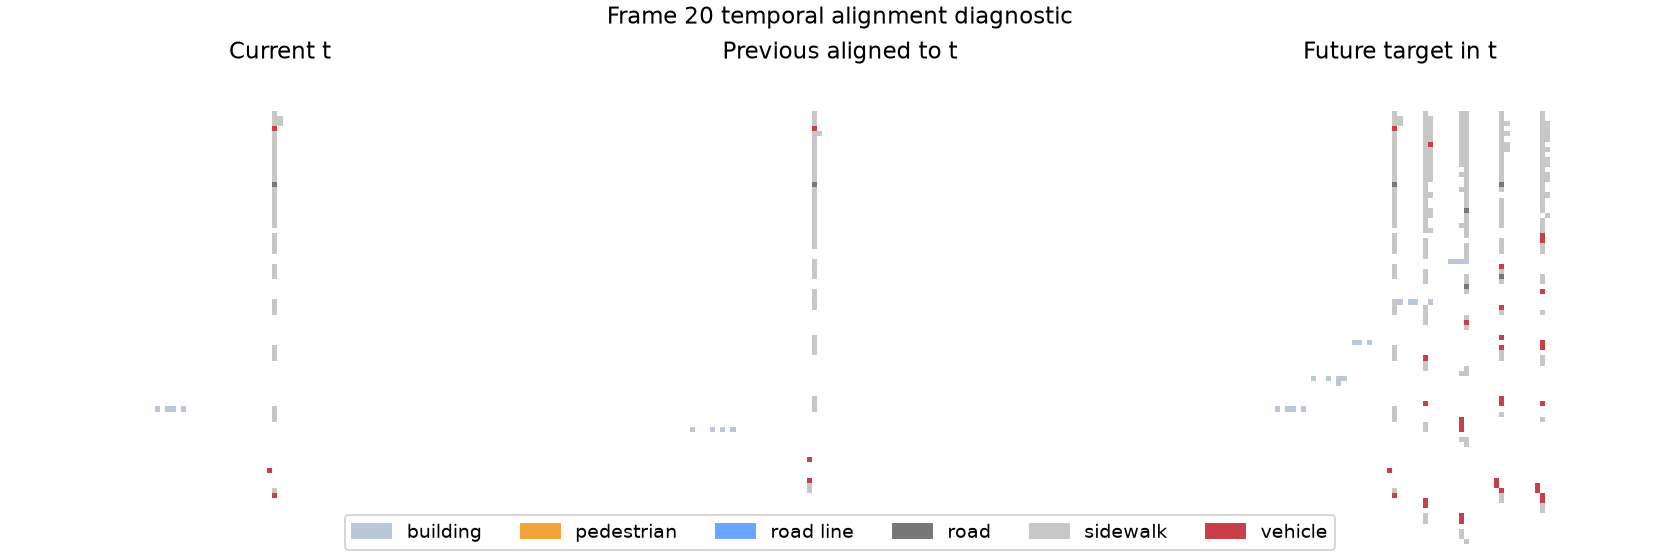

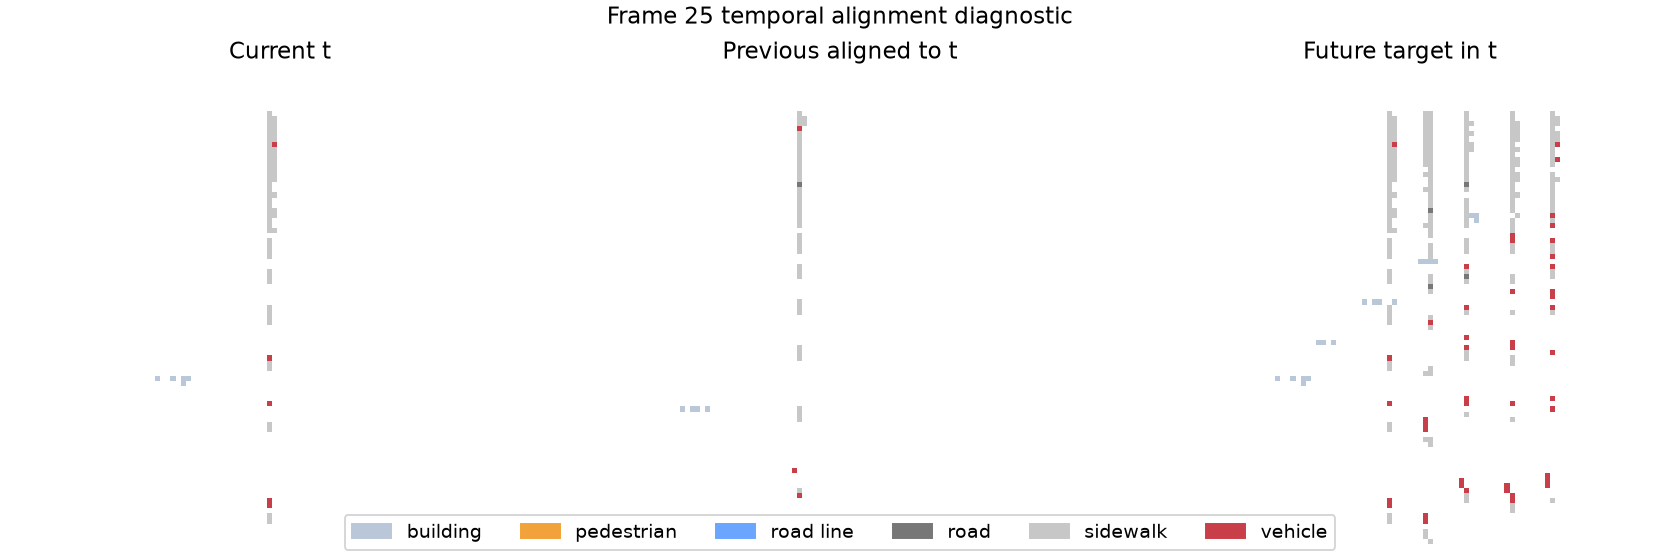

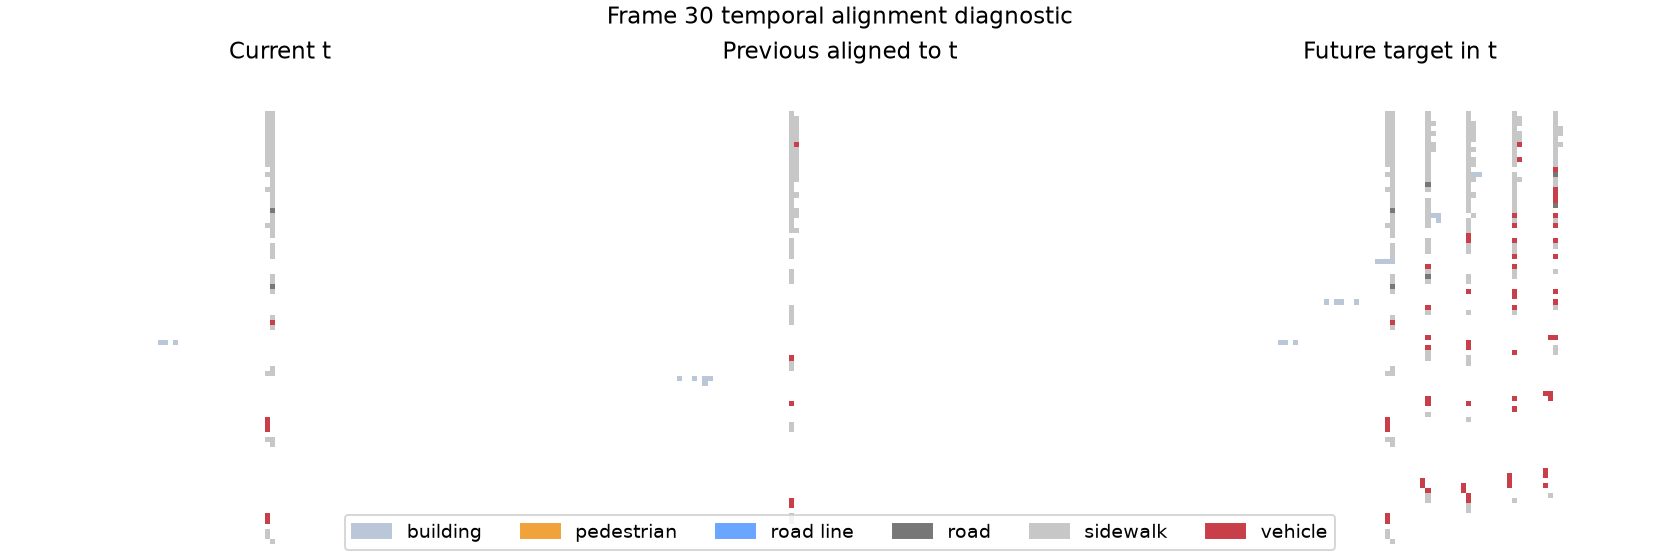

In [7]:
alignment = load_summary(future_artifacts.alignment_summary)
print(json.dumps({k: v for k, v in alignment.items() if k != "records"}, indent=2))
for image_path in alignment["image_paths"]:
    display(Image(filename=image_path))


## 8. Visual Checks


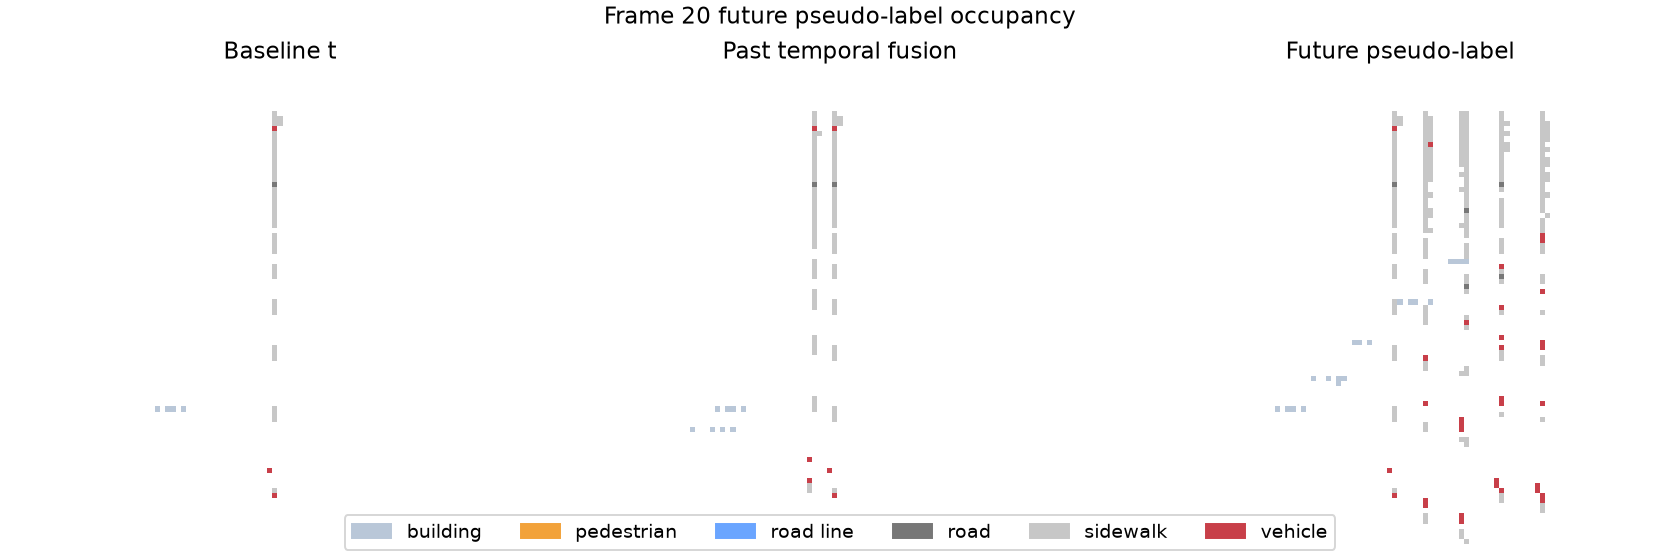

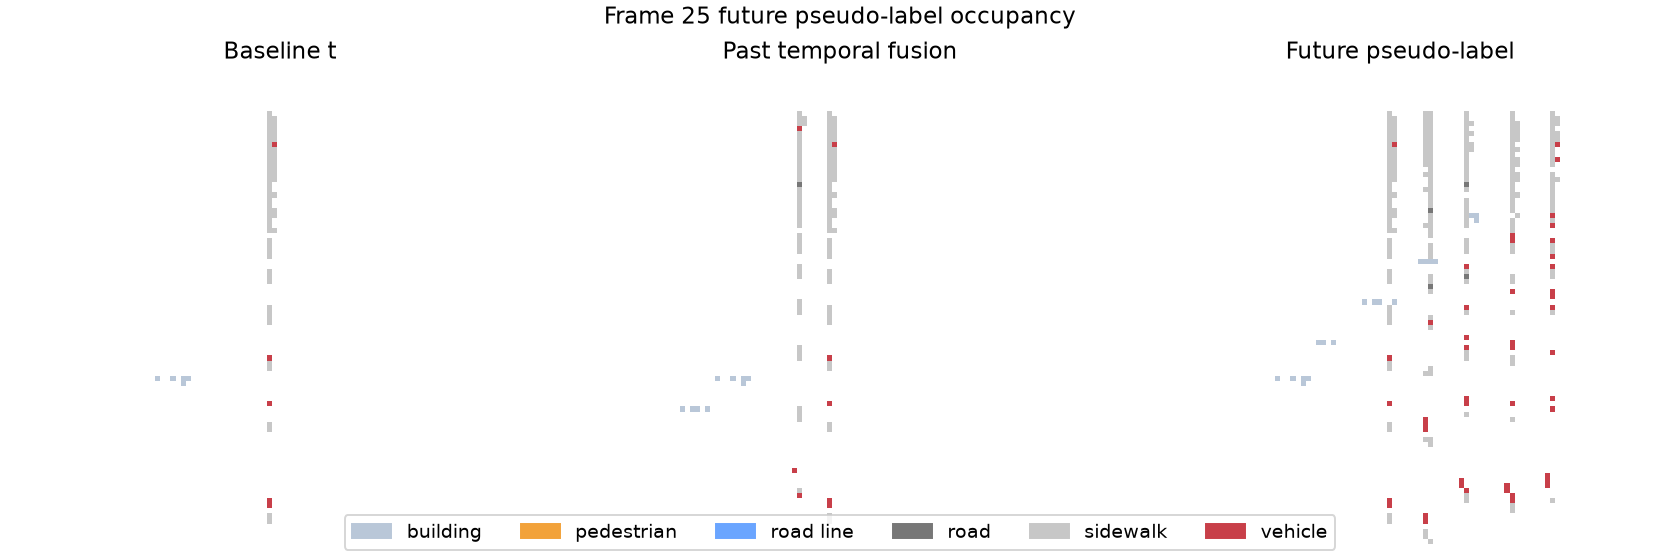

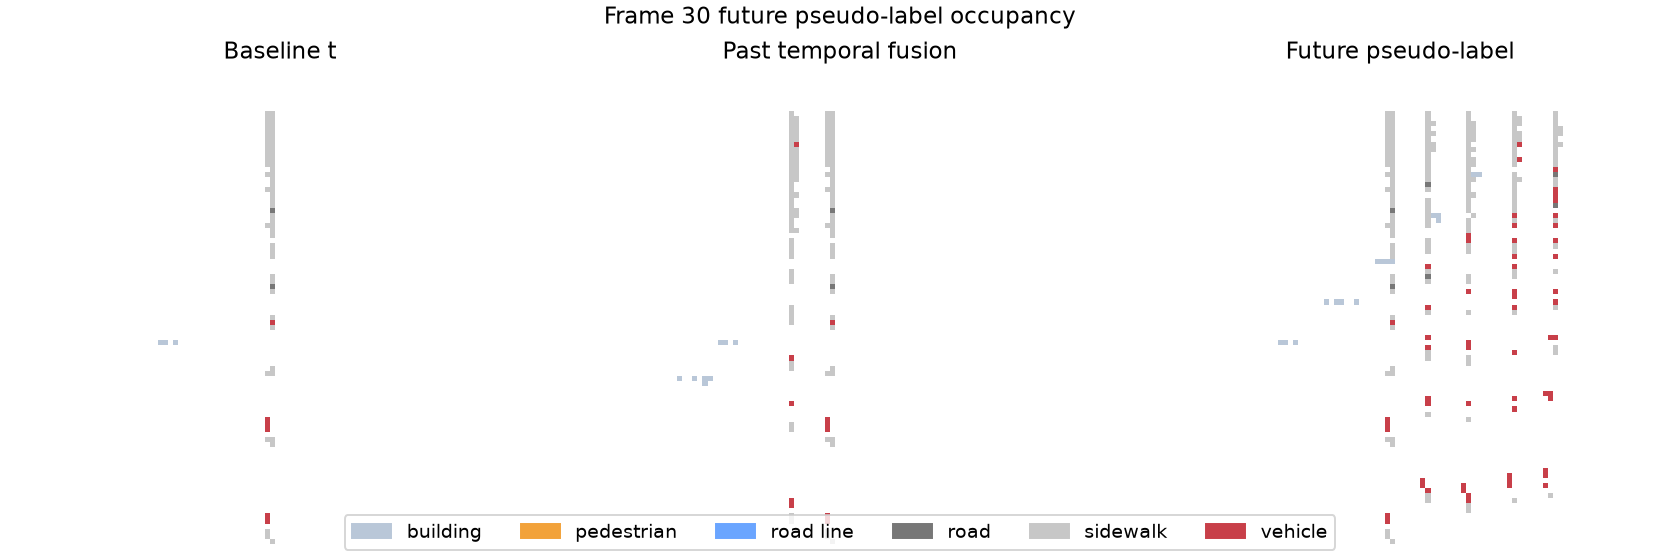

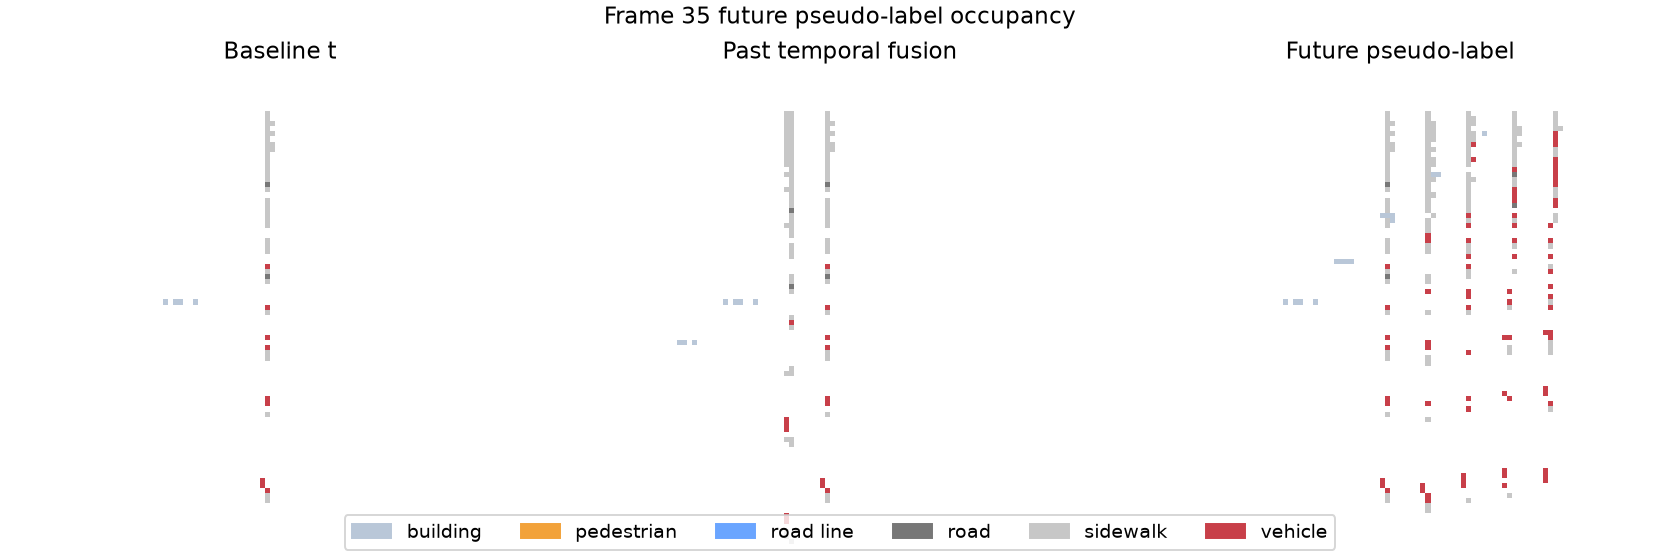

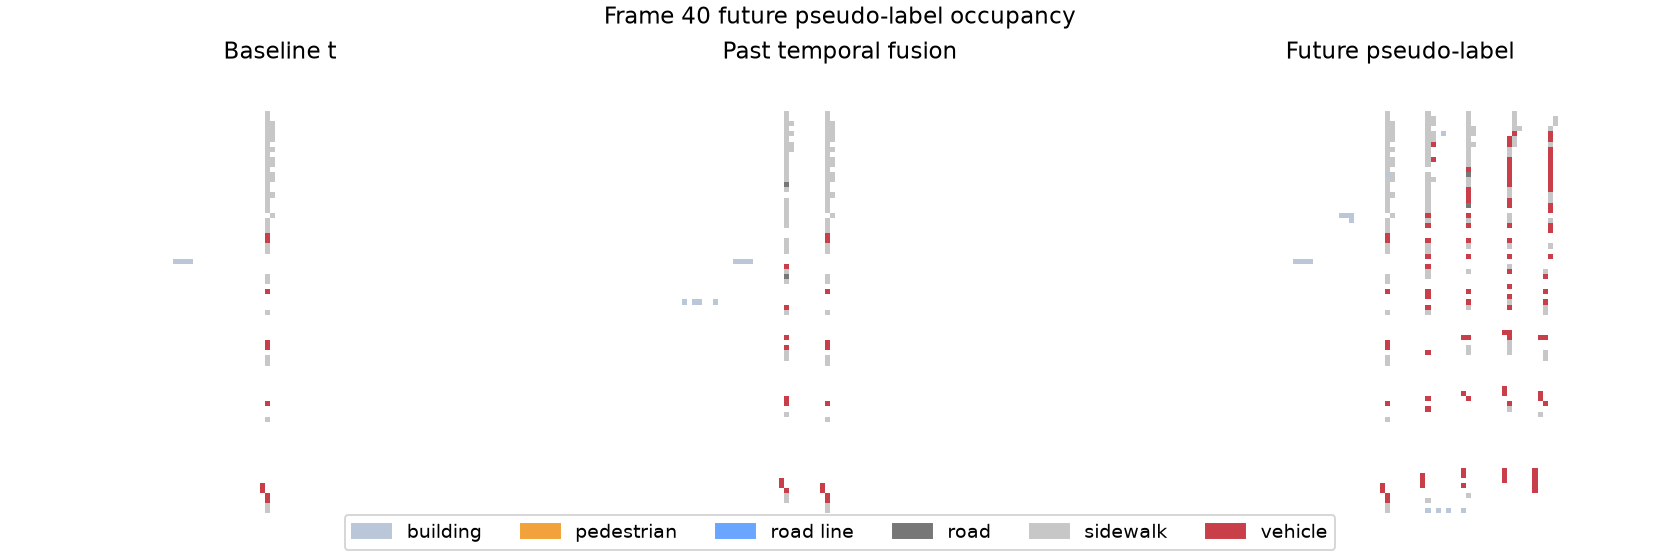

In [8]:
for image_path in future_artifacts.bev_images[:5]:
    display(Image(filename=str(image_path)))


## 9. Interpretation Notes


In [9]:
notes = []
for row in rows:
    if not row["informative"]:
        notes.append(f"{row['class_name']}: non-informative empty union in this bounded run.")
    elif row["delta"] >= 0:
        notes.append(f"{row['class_name']}: temporal fusion improved/preserved future-pseudo IoU by {row['delta']:+.3f}.")
    else:
        notes.append(f"{row['class_name']}: temporal fusion reduced future-pseudo IoU by {row['delta']:+.3f}; inspect alignment and ablation images.")
notes.append("These are pseudo-label metrics from sparse projected LiDAR, not true dense 3D occupancy ground truth.")
display(Markdown("\n".join(f"- {note}" for note in notes)))


- pedestrian: non-informative empty union in this bounded run.
- road: temporal fusion improved/preserved future-pseudo IoU by +0.000.
- vehicle: temporal fusion improved/preserved future-pseudo IoU by +0.016.
- These are pseudo-label metrics from sparse projected LiDAR, not true dense 3D occupancy ground truth.